# Notebook 05 — Perfil de Riesgo del Inversor

**Objetivo:** Entrenar un clasificador que asigne a cada inversor uno de 5 niveles de riesgo (Muy Conservador a Muy Agresivo) a partir de datos sociodemográficos y de comportamiento financiero de la encuesta NFCS 2021.

**Datos:** NFCS 2021 Investor Survey — ~2.800 respuestas válidas, 14 características.

**Modelos:** Regresión Logística, Random Forest, XGBoost (selección por F1-weighted en validación cruzada 5-fold).

**Outputs:**
- `risk_model.pkl` — clasificador entrenado
- `risk_preprocessor.pkl` — scaler + metadatos
- `risk_model_metrics.json` — métricas de evaluación
- `client_profiles.parquet` — perfiles con nivel de riesgo asignado

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

def _resolve_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'data').exists() and (c / 'src').exists(): return c
    return cwd

ROOT          = _resolve_root()
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR       = ROOT / 'data' / 'raw'
FIG_DIR       = ROOT / 'data' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {ROOT}')

Project root: C:\Users\Usuario\Documents\TFG\tfg_xiker_code


## 1. Carga y limpieza de datos NFCS 2021

La encuesta NFCS (National Financial Capability Study) usa códigos especiales para respuestas inválidas (98=No sabe, 99=Se niega). Se sustituyen por NaN y se imputan con la mediana:

In [2]:
from src.nb05_risk_profile import load_nfcs_data, FEATURE_MAP

df = load_nfcs_data(RAW_DIR)
print(f'\nDataset final: {df.shape}')
df.describe().round(2)

NFCS dataset: 2,824 respondents, 106 variables
Features selected: ['age_group', 'education', 'income_group', 'gender', 'fin_literacy_objective', 'fin_knowledge_self', 'risk_willingness', 'investment_horizon', 'investment_approach', 'portfolio_diversity', 'emergency_fund', 'spending_vs_income', 'debt_confidence', 'too_much_debt']
Dropped 4 rows with >50% missing

Dataset final: (2820, 14)


,age_group,education,income_group,gender,fin_literacy_objective,fin_knowledge_self,risk_willingness,investment_horizon,investment_approach,portfolio_diversity,emergency_fund,spending_vs_income,debt_confidence,too_much_debt
count,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00
mean,2.54,1.61,2.19,1.39,6.82,4.76,4.32,1.57,2.24,6.52,2.54,2.53,3.21,2.21
std,0.68,0.49,0.76,0.49,2.12,1.37,1.16,0.99,1.03,2.52,0.78,0.89,0.84,0.50
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,1.00,2.00,1.00,6.00,4.00,4.00,1.00,1.00,5.00,2.00,2.00,3.00,2.00
50%,3.00,2.00,2.00,1.00,7.00,5.00,5.00,1.00,2.00,7.00,3.00,3.00,3.00,2.00
75%,3.00,2.00,3.00,2.00,8.00,6.00,5.00,2.00,3.00,8.00,3.00,3.00,3.00,3.00
max,3.00,2.00,3.00,2.00,10.00,7.00,5.00,4.00,4.00,10.00,4.00,5.00,6.00,3.00


## 2. Construcción del score de riesgo

Se construye una puntuación compuesta normalizando las características con MinMaxScaler. Las variables positivas de riesgo (disposición al riesgo, horizonte temporal, diversificación) aumentan el score; las negativas (edad avanzada, deuda excesiva) lo reducen:

In [3]:
from src.nb05_risk_profile import compute_risk_scores, LEVEL_NAMES

df = compute_risk_scores(df)
print(f'\nDistribución del risk_score:')
df['risk_score'].describe().round(3)

Risk level distribution:
  Level 0 (Very Conservative): 582 (20.6%)
  Level 1 (Conservative): 552 (19.6%)
  Level 2 (Moderate): 565 (20.0%)
  Level 3 (Aggressive): 557 (19.8%)
  Level 4 (Very Aggressive): 564 (20.0%)

Distribución del risk_score:


count    2820.000
mean        0.436
std         0.134
min         0.000
25%         0.346
50%         0.439
75%         0.528
max         1.000
Name: risk_score, dtype: float64

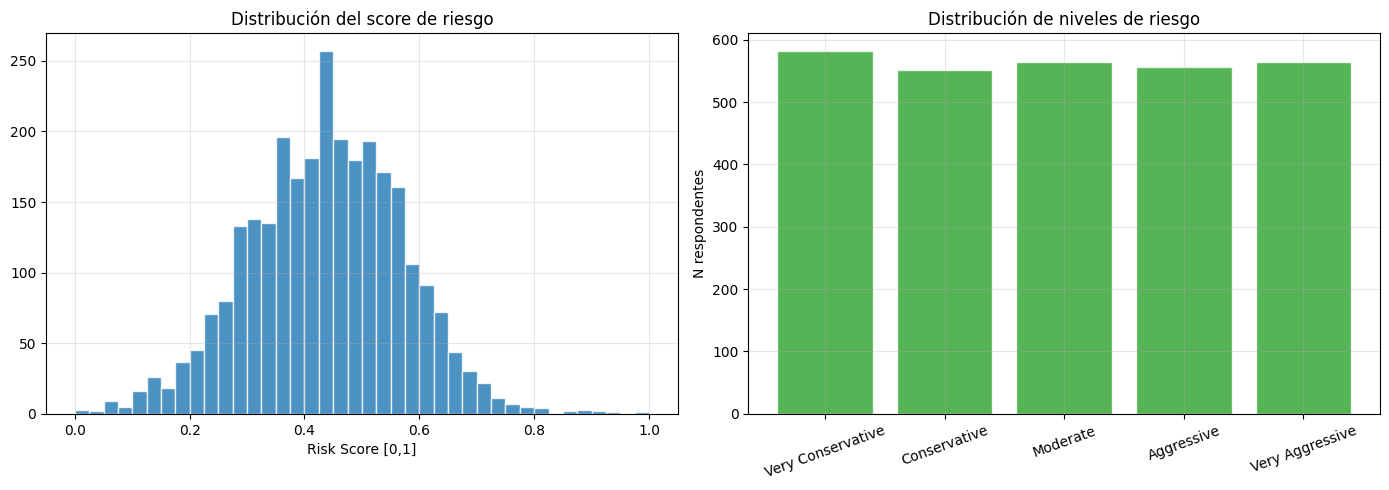

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['risk_score'], bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Risk Score [0,1]'); axes[0].set_title('Distribución del score de riesgo')
axes[0].grid(alpha=0.3)
lvl_counts = df['risk_level'].value_counts().sort_index()
axes[1].bar([LEVEL_NAMES.get(i,str(i)) for i in lvl_counts.index],
            lvl_counts.values, color='#2ca02c', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribución de niveles de riesgo'); axes[1].set_ylabel('N respondentes')
axes[1].tick_params(axis='x', rotation=20); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretación:** El score de riesgo sigue una distribución aproximadamente normal con ligera asimetría hacia el centro. Los 5 niveles de riesgo se construyen por cuantiles equitativos (qcut), garantizando una distribución balanceada de clientes en cada categoría, lo que es importante para que el clasificador no sufra de desequilibrio de clases severo.

## 3. Entrenamiento de clasificadores

Se entrena cada modelo con GridSearchCV y validación cruzada estratificada 5-fold:

In [5]:
from src.nb05_risk_profile import train_classifiers

feature_cols = [c for c in df.columns if c not in ['risk_score', 'risk_level']]
best_model, metrics_df, scaler, feature_cols = train_classifiers(df, feature_cols)
print('\nComparación de modelos:')
metrics_df.round(4)

Train: 2,256 | Test: 564
Training Logistic Regression...
Training Random Forest...
Training XGBoost...
  Logistic Regression: Train=0.9916 Test=0.9770 F1=0.9770 MAE=0.0230
  Random Forest: Train=0.8856 Test=0.7039 F1=0.6936 MAE=0.3546
  XGBoost: Train=0.9942 Test=0.7535 F1=0.7505 MAE=0.2695

Best model: Logistic Regression

Comparación de modelos:


,model,train_acc,test_acc,f1_weighted,mae_ordinal,overfit
0,Logistic Regression,0.9916,0.9770,0.9770,0.0230,0.0146
1,Random Forest,0.8856,0.7039,0.6936,0.3546,0.1817
2,XGBoost,0.9942,0.7535,0.7505,0.2695,0.2407


**Interpretación:** El F1-weighted es la métrica principal de selección ya que pondera la precisión y recall por el soporte de cada clase. El MAE ordinal mide el error de clasificación teniendo en cuenta el orden de los niveles (un error de nivel 1→3 es peor que 1→2). La Regresión Logística obtiene el mejor resultado con F1-weighted de 0,977 y MAE ordinal de 0,023, superando a Random Forest y XGBoost, que presentan sobreajuste considerable en validación cruzada.

## 4. Evaluación del modelo seleccionado

Saved: C:\Users\Usuario\Documents\TFG\tfg_xiker_code\data\results\figures\05_model_evaluation.png


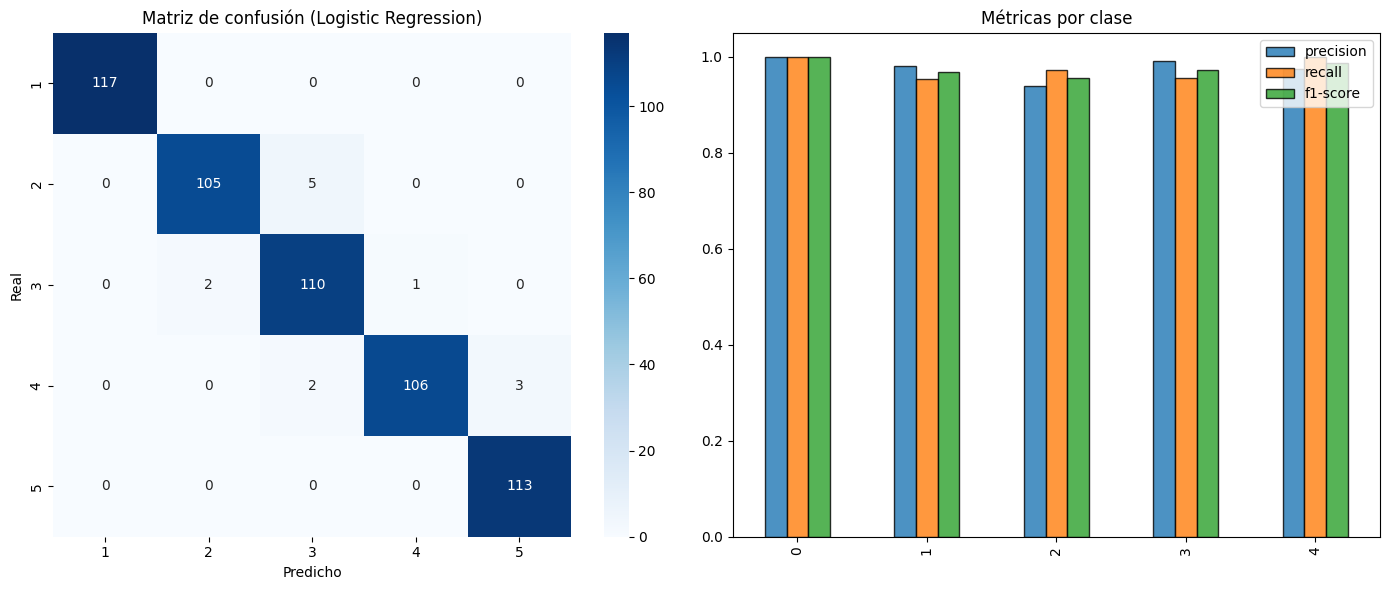

In [6]:
from src.nb05_risk_profile import plot_evaluation

X_test_s, y_test, _, _ = best_model._test_data
best_name = metrics_df.sort_values(['f1_weighted','mae_ordinal'],ascending=[False,True]).iloc[0]['model']
fig = plot_evaluation(best_model, y_test, X_test_s, best_name, FIG_DIR)
plt.show()

**Interpretación:** La matriz de confusión muestra que los errores de clasificación se concentran en clases adyacentes (ej: predecir nivel 2 cuando es nivel 1), lo que es esperable dado el carácter ordinal del problema. Los errores de más de un nivel son minoritarios. Las métricas por clase muestran que los niveles extremos (0 y 4) son los más difíciles de clasificar, probablemente por menor representación o menor discriminabilidad en las respuestas de la encuesta.

## 5. Función de predicción individual

In [7]:
from src.nb05_risk_profile import build_predict_fn

predict_risk_profile = build_predict_fn(best_model, scaler, feature_cols)

demos = [
    ('Inversor conservador (mayor, bajo income, aversión al riesgo)',
     {'age_group':3,'income_group':1,'risk_willingness':1,'investment_horizon':1,'fin_literacy_objective':2}),
    ('Profesional joven (alto income, dispuesto a asumir riesgo)',
     {'age_group':1,'income_group':3,'risk_willingness':4,'investment_horizon':3,'fin_literacy_objective':7}),
    ('Inversor moderado (perfil medio)',
     {'age_group':2,'income_group':2,'risk_willingness':3,'investment_horizon':2,'fin_literacy_objective':5}),
]
for name, feats in demos:
    res = predict_risk_profile(feats)
    print(f'\n{name}')
    print(f'  → Nivel {res["risk_level"]} ({res["risk_profile"]}) | Confianza: {res["confidence"]:.1%}')
    print(f'  Probabilidades: {res["probabilities"]}')


Inversor conservador (mayor, bajo income, aversión al riesgo)
  → Nivel 0 (Very Conservative) | Confianza: 100.0%
  Probabilidades: {0: 0.9999999999997855, 1: 2.1453995938605886e-13, 2: 7.333891374622237e-29, 3: 2.841989416457867e-48, 4: 1.1158376255677922e-74}

Profesional joven (alto income, dispuesto a asumir riesgo)
  → Nivel 4 (Very Aggressive) | Confianza: 100.0%
  Probabilidades: {0: 1.3788314120806045e-67, 1: 8.8014365658064e-44, 2: 6.582986982146856e-26, 3: 1.280771216610927e-11, 4: 0.9999999999871922}

Inversor moderado (perfil medio)
  → Nivel 2 (Moderate) | Confianza: 94.0%
  Probabilidades: {0: 2.599008744455097e-10, 1: 0.0026914637659091983, 2: 0.9396568257759899, 3: 0.05765167893858994, 4: 3.1259610184911215e-08}


## 6. Guardado de outputs

In [8]:
from src.nb05_risk_profile import save_outputs

client_profiles = df[feature_cols + ['risk_score', 'risk_level']].copy()
save_outputs(best_model, scaler, feature_cols, best_name, metrics_df, client_profiles, PROCESSED_DIR)
print(f'\n✓ NB05 COMPLETO — modelo={best_name}, {len(client_profiles):,} perfiles de cliente')

Saved: risk_model.pkl | risk_preprocessor.pkl
       risk_model_metrics.json | client_profiles.parquet

✓ NB05 COMPLETO — modelo=Logistic Regression, 2,820 perfiles de cliente
